# UK A-Level Algorithm Fairness Simulation

This notebook presents a simplified simulation inspired by the UK A-Level Algorithm controversy of 2020. During the COVID-19 pandemic, traditional examinations were cancelled and algorithmic moderation was used to adjust student grades. One of the major criticisms of the system was its reliance on historical school performance, which could influence the outcomes of individual students.

The objective of this notebook is not to recreate the original Ofqual algorithm, but to demonstrate how historical school-level data can affect individual grades and raise fairness concerns in algorithmic decision-making.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

The Student Performance Dataset is used as the basis for this simulation. Final student grades (G3) are treated as teacher-assessed grades, while average school performance is used to represent historical school performance.
The dataset covers students from two Portuguese secondary schools:
- **GP** — Gabriel Pereira (urban, 423 students)
- **MS** — Mousinho da Silveira (rural, 226 students)

This allows us to create a simplified educational example of how algorithmic grade adjustment can influence student outcomes.


In [7]:
df = pd.read_csv("/content/student-por.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [8]:
df[['school','G3']].head()

,school,G3
0,GP,11
1,GP,11
2,GP,12
3,GP,14
4,GP,13


## Simulating Algorithmic Grade Adjustment

To illustrate the concerns discussed in the accompanying report, adjusted grades are calculated using both individual student performance and historical school performance.

The adjustment formula used in this notebook is intentionally simplified and should not be interpreted as the actual Ofqual grading algorithm.

In [9]:
df['Teacher_Predicted_Grade'] = df['G3']

In [10]:
school_avg = df.groupby('school')['G3'].mean()

df['Historical_School_Average'] = (
    df['school'].map(school_avg)
)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,Teacher_Predicted_Grade,Historical_School_Average
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,4,0,11,11,11,12.576832
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,2,9,11,11,11,12.576832
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,6,12,13,12,12,12.576832
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,0,14,14,14,14,12.576832
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,0,11,13,13,13,12.576832


In [11]:
df['Adjusted_Grade'] = (
    0.4 * df['Teacher_Predicted_Grade']
    +
    0.6 * df['Historical_School_Average']
)

In [12]:
df['Grade_Change'] = (
    df['Adjusted_Grade'] -
    df['Teacher_Predicted_Grade']
)

df[['school',
    'Teacher_Predicted_Grade',
    'Adjusted_Grade',
    'Grade_Change']].head()

,school,Teacher_Predicted_Grade,Adjusted_Grade,Grade_Change
0,GP,11,11.946099,0.946099
1,GP,11,11.946099,0.946099
2,GP,12,12.346099,0.346099
3,GP,14,13.146099,-0.853901
4,GP,13,12.746099,-0.253901


In [13]:
downgraded = (
    df['Grade_Change'] < 0
).sum()

print("Students downgraded:", downgraded)

Students downgraded: 327


## Fairness Analysis and Visualizations

The following visualizations compare teacher-assessed grades with algorithm-adjusted grades and help identify how individual outcomes can be influenced by school-level historical performance.

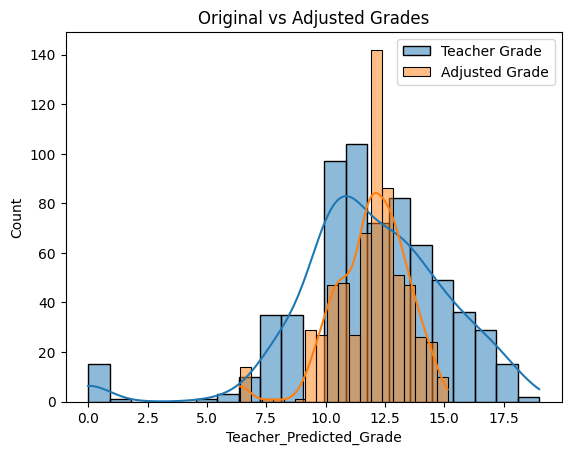

In [14]:
sns.histplot(
    df['Teacher_Predicted_Grade'],
    label='Teacher Grade',
    kde=True
)

sns.histplot(
    df['Adjusted_Grade'],
    label='Adjusted Grade',
    kde=True
)

plt.legend()
plt.title("Original vs Adjusted Grades")
plt.show()

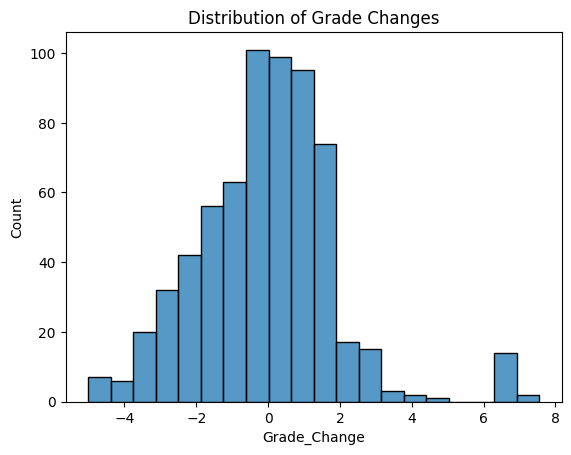

In [22]:
sns.histplot(df['Grade_Change'], bins=20)
plt.title("Distribution of Grade Changes")
plt.show()

In [19]:
top_affected = (
    df.sort_values(
        'Grade_Change'
    )
    .head(10)
)

top_affected[
    ['school',
     'Teacher_Predicted_Grade',
     'Adjusted_Grade',
     'Grade_Change']
]

,school,Teacher_Predicted_Grade,Adjusted_Grade,Grade_Change
636,MS,19,13.990265,-5.009735
606,MS,18,13.590265,-4.409735
594,MS,18,13.590265,-4.409735
596,MS,18,13.590265,-4.409735
617,MS,18,13.590265,-4.409735
549,MS,18,13.590265,-4.409735
509,MS,18,13.590265,-4.409735
338,GP,19,15.146099,-3.853901
595,MS,17,13.190265,-3.809735
630,MS,17,13.190265,-3.809735


In [20]:
downgraded_pct = (
    (df['Grade_Change'] < 0)
    .mean()
    * 100
)

print(
    f"{downgraded_pct:.2f}% of students received lower grades after adjustment."
)

50.39% of students received lower grades after adjustment.


## Conclusion

This simulation demonstrates how group-level historical information can influence individual outcomes. Although simplified, the results highlight a key ethical concern raised by the UK A-Level Algorithm case: students may be affected not only by their own performance, but also by historical patterns associated with their school.

The exercise reinforces the importance of fairness, transparency, and human oversight when deploying AI systems in high-stakes domains such as education.
